# 04 - EXPLORATION VISUELLE DU CORPUS

Apercu statistique et graphique de l'ensemble du corpus annoté : longueur de phrases, distribution des POS, top lemmes par auteur, courbe de Zipf, richesse lexicale.

Tout part du chargement uniformisé via `pipeline.corpus.charger_corpus()`.


## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/home/gau/projets/nlp/projet_nlp_app
README.md                audit_corpus.py     pg_catalog.csv
app/                     diagnostic_mmr.png  pipeline/
audit_clean_border.py    diagnostic_mmr.py   requirements.txt
audit_clean_borders.txt  figures/            scripts/
audit_corpus.csv         models/
audit_corpus.png         notebooks/


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pipeline.corpus import charger_corpus

CFG = {
    "figures_dir": Path("figures"),
}
CFG["figures_dir"].mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"


## Chargement

In [3]:
corpus = charger_corpus()
print(f"\n{len(corpus)} livres :")
for c in corpus[:5]:
    print(f"  {c['auteur']:35s} -- {c['livre']:40s} ({c['genre']})")


Chargement de 26 livres annotes...
  override genre: pg17989_le_comte_de_monte_cristo_tome_i historical_fiction -> adventure
  1 override(s) de genre appliques.
  26 livres charges

26 livres :
  Dumas Alexandre                     -- Le Comte De Monte Cristo Tome Ii         (adventure)
  Raspe Rudolf Erich                  -- Aventures De Baron De Munchausen         (adventure)
  Fusil Louise                        -- Souvenirs Dune Actrice 23                (biography)
  Marmont Auguste Frederic Louis Viesse De Duc De Raguse -- Memoires Du Marechal Marmont Duc De Raguse 39 (biography)
  Rouquette Louis Frederic            -- Lepopee Blanche                          (biography)


## Tableau récapitulatif par livre

Une ligne par livre : nombre de tokens, nombre de phrases, taille du vocabulaire (lemmes), longueur moyenne de phrase.


In [4]:
def stats_livre(c):
    df = c["df"]
    return {
        "auteur":     c["auteur"],
        "livre":      c["livre"],
        "genre":      c["genre"],
        "n_tokens":   len(df),
        "n_phrases":  df["sent_id"].nunique(),
        "vocab":      df["lemma"].nunique(),
        "tok_phrase": len(df) / df["sent_id"].nunique(),
    }

stats = pd.DataFrame([stats_livre(c) for c in corpus])
stats.sort_values("n_tokens", ascending=False)


,auteur,livre,genre,n_tokens,n_phrases,vocab,tok_phrase
12,Hugo Victor,Lhomme Qui Rit,novel,249895,15870,15506,15.746377
15,Zola Emile,Germinal,novel,212183,10375,8895,20.451373
14,Zola Emile,Au Bonheur Des Dames,novel,189577,10023,8415,18.914197
22,Scudery Madeleine De,Mademoiselle De Scudery Sa Vie Et Sa Correspon...,poetry,162598,5920,10102,27.465878
7,Dumas Alexandre,Le Comte De Monte Cristo Tome I,adventure,155599,7506,7691,20.729949
0,Dumas Alexandre,Le Comte De Monte Cristo Tome Ii,adventure,152125,7612,7769,19.984892
11,Zevaco Michel,Les Pardaillan Tome 03 La Fausta,historical_fiction,150407,10151,7157,14.816964
16,Zola Emile,Le Docteur Pascal,novel,146043,6792,7260,21.502208
10,Weyman Stanley John,La Cocarde Rouge,historical_fiction,139605,8450,8234,16.521302
24,Sacher Masoch Leopold Ritter Von,La Pecheuse Dames,scifi_fantasy,139004,9063,6770,15.337526


## Distribution des longueurs de phrases

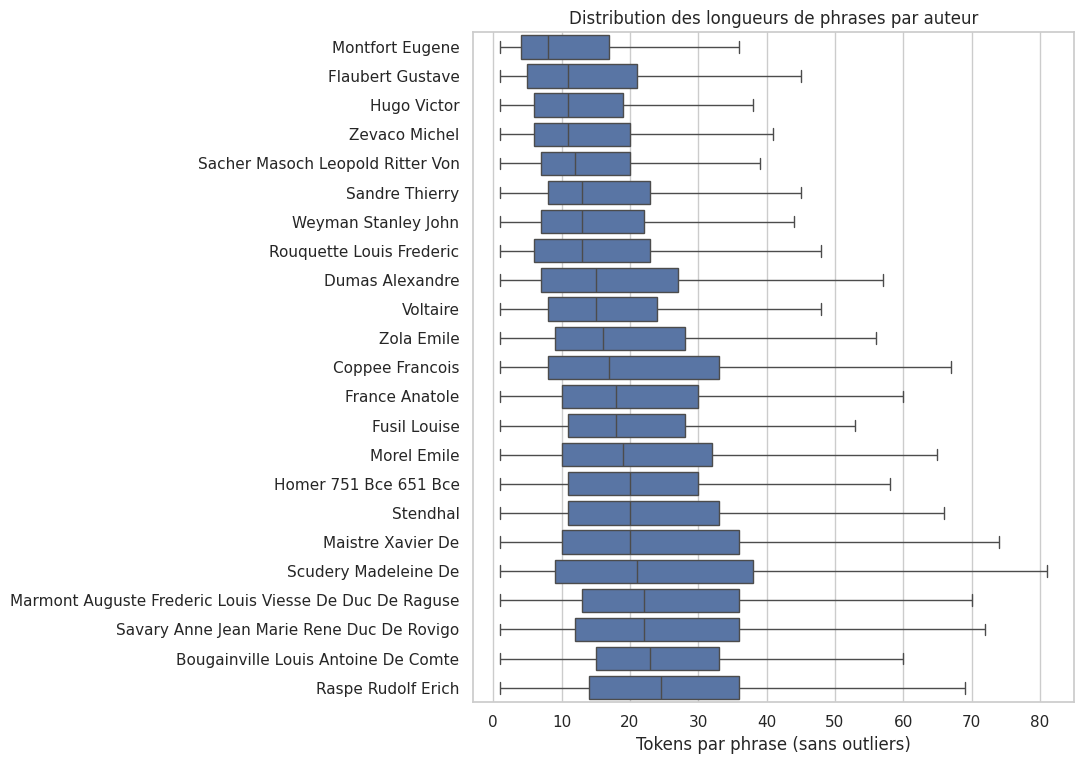

In [5]:
lignes_phrases = []
for c in corpus:
    longueurs = c["df"].groupby("sent_id").size()
    for n in longueurs:
        lignes_phrases.append({"auteur": c["auteur"], "genre": c["genre"], "n_tokens": n})
phrases_df = pd.DataFrame(lignes_phrases)

ordre_auteurs = (
    phrases_df.groupby("auteur")["n_tokens"].median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(11, max(4, 0.3 * len(corpus))))
sns.boxplot(data=phrases_df, x="n_tokens", y="auteur", order=ordre_auteurs,
            showfliers=False, ax=ax)
ax.set_xlabel("Tokens par phrase (sans outliers)")
ax.set_ylabel("")
ax.set_title("Distribution des longueurs de phrases par auteur")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "longueurs_phrases.png")
plt.show()


## Distribution des parties du discours

Quels sont les profils d'usage des grandes catégories grammaticales par auteur ?


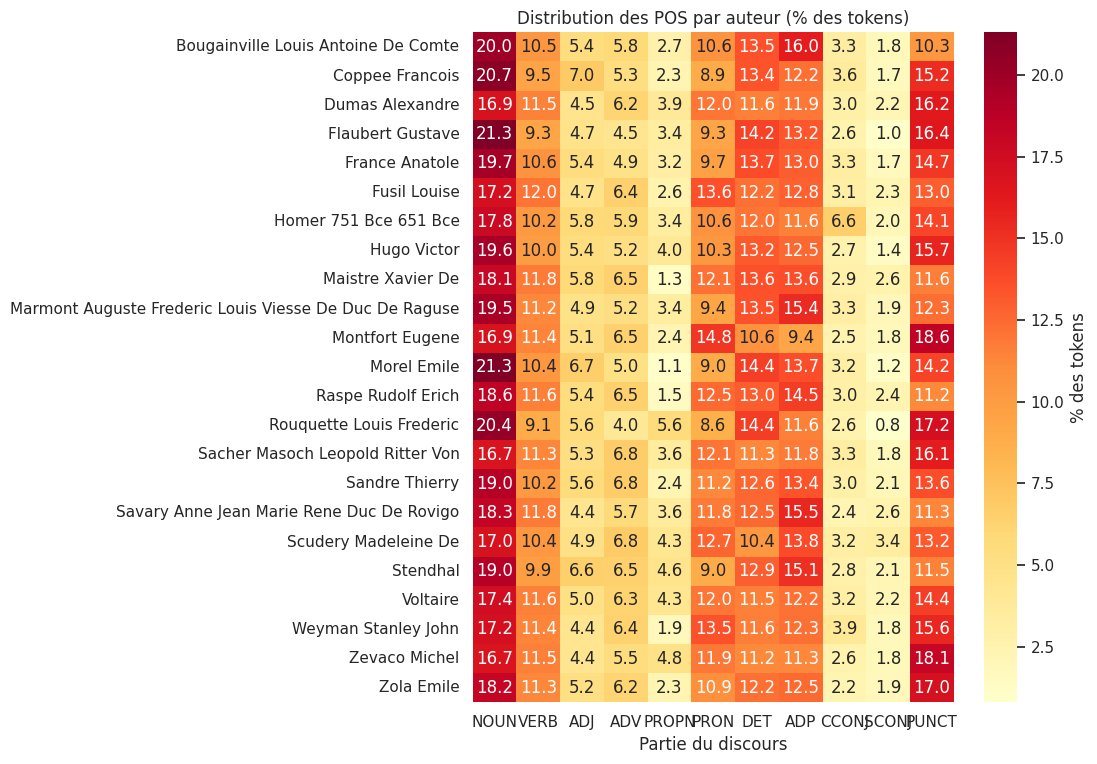

In [6]:
POS_AFFICHES = ["NOUN", "VERB", "ADJ", "ADV", "PROPN", "PRON",
                "DET", "ADP", "CCONJ", "SCONJ", "PUNCT"]

lignes_pos = []
for c in corpus:
    df = c["df"]
    counts = df["pos"].value_counts()
    for pos in POS_AFFICHES:
        lignes_pos.append({
            "auteur": c["auteur"], 
            "pos": pos,
            "nb": int(counts.get(pos, 0)), # On stocke le nombre brut
        })
pos_df = pd.DataFrame(lignes_pos)

# 1. On somme les occurrences par auteur et par POS (au cas où un auteur a plusieurs textes)
pos_df = pos_df.groupby(["auteur", "pos"])["nb"].sum().reset_index()

# 2. On recalcule le pourcentage par auteur sur le total agrégé
total_par_auteur = pos_df.groupby("auteur")["nb"].transform("sum")
pos_df["pct"] = (pos_df["nb"] / total_par_auteur) * 100

# Heatmap
pivot = pos_df.pivot(index="auteur", columns="pos", values="pct")
pivot = pivot[POS_AFFICHES]

fig, ax = plt.subplots(figsize=(11, max(4, 0.3 * len(corpus))))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% des tokens"})
ax.set_xlabel("Partie du discours")
ax.set_ylabel("")
ax.set_title("Distribution des POS par auteur (% des tokens)")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "pos_par_auteur.png")
plt.show()


## Top lemmes hors mots-outils

On garde les lemmes alphabetiques, hors stopwords, hors ponctuation, et on prend le top 15 par auteur.


In [7]:
def top_lemmes(df, n=15):
    masque = df["is_alpha"] & ~df["is_stop"] & ~df["is_punct"]
    return df.loc[masque, "lemma"].str.lower().value_counts().head(n)

# Affichage tabulaire
for c in corpus[:5]:
    print(f"\n--- {c['auteur']} -- {c['livre']} ---")
    print(top_lemmes(c['df']).to_string())



--- Dumas Alexandre -- Le Comte De Monte Cristo Tome Ii ---
lemma
comte       705
monsieur    550
avoir       545
faire       522
bien        517
être        502
monte       412
cristo      406
franz       398
homme       391
albert      380
venir       271
voir        270
vouloir     242
demander    240

--- Raspe Rudolf Erich -- Aventures De Baron De Munchausen ---
lemma
être        138
avoir       116
faire       105
grand        98
trouver      73
bien         63
voir         61
temps        60
mettre       59
prendre      57
jour         55
voyage       44
mer          43
terre        42
aventure     40

--- Fusil Louise -- Souvenirs Dune Actrice 23 ---
lemma
être        365
faire       288
avoir       175
monsieur    168
bien        160
voir        152
temps       148
venir       141
grand       139
vouloir     122
donner      111
fort        104
femme       104
prendre      99
dire         95

--- Marmont Auguste Frederic Louis Viesse De Duc De Raguse -- Memoires Du Marechal Ma

## Courbe de Zipf

Loi empirique : la fréquence du n-ième mot le plus fréquent est inversement proportionnelle à son rang. En log-log, on s'attend a une droite.


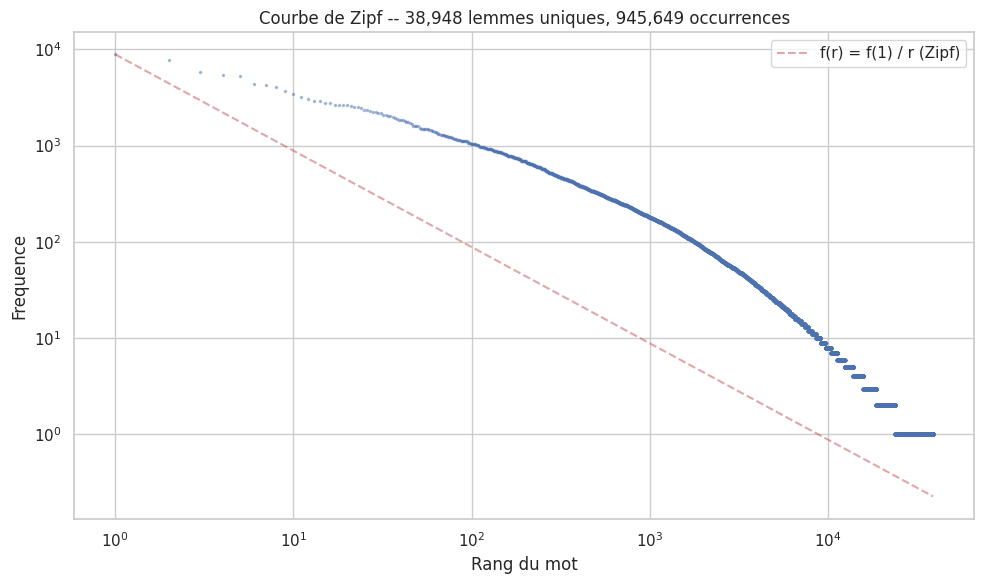

In [8]:
import numpy as np

# Concatener les lemmes filtres de tout le corpus
tous_lemmes = pd.concat([
    c["df"].loc[
        c["df"]["is_alpha"] & ~c["df"]["is_stop"] & ~c["df"]["is_punct"],
        "lemma"
    ].str.lower()
    for c in corpus
])

freq = tous_lemmes.value_counts()
rangs = np.arange(1, len(freq) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(rangs, freq.values, ".", alpha=0.4, markersize=3)
# Reference theorique : f(r) = f(1) / r
ref = freq.iloc[0] / rangs
ax.loglog(rangs, ref, "r--", alpha=0.5, label="f(r) = f(1) / r (Zipf)")
ax.set_xlabel("Rang du mot")
ax.set_ylabel("Frequence")
ax.set_title(f"Courbe de Zipf -- {len(freq):,} lemmes uniques, {freq.sum():,} occurrences")
ax.legend()
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "zipf.png")
plt.show()


## Richesse lexicale : vocabulaire vs longueur

Loi de Heaps : la taille du vocabulaire croit comme une racine de la longueur du texte.


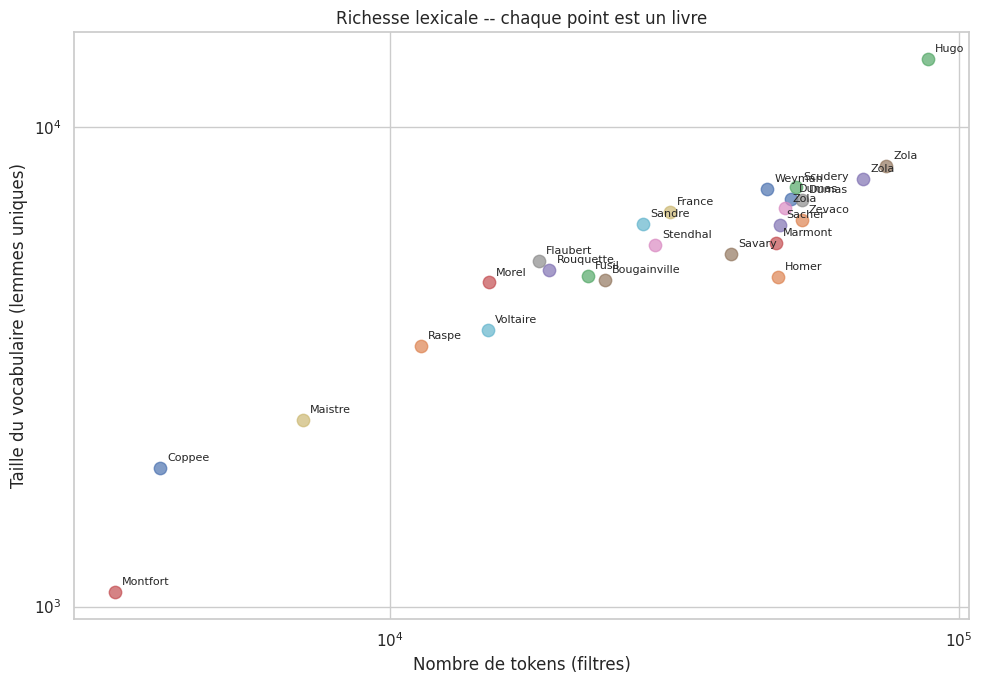

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
for c in corpus:
    n_tok = len(c["lemmes"])
    n_vocab = len(set(c["lemmes"]))
    ax.scatter(n_tok, n_vocab, s=80, alpha=0.7)
    ax.annotate(c["auteur"].split()[0],
                (n_tok, n_vocab),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Nombre de tokens (filtres)")
ax.set_ylabel("Taille du vocabulaire (lemmes uniques)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Richesse lexicale -- chaque point est un livre")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "richesse_lexicale.png")
plt.show()
